In [2]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

In [3]:
flares = pd.read_csv("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210101_20260130_version1_python.csv")

In [4]:
flares.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [5]:
top100 = flares.sort_values("goes_estimated_mean_flux", ascending=False).head(100)
top100

,start_UTC,end_UTC,peak_UTC,4-10 keV,10-15 keV,15-25 keV,25-50 keV,50-84 keV,bkg 4-10 keV,bkg 10-15 keV,...,flare_id,sidelobes_ratio,goes_estimated_min_class,goes_estimated_max_class,goes_estimated_mean_class,goes_estimated_min_flux,goes_estimated_max_flux,goes_estimated_mean_flux,error_with_imaging,cpd_filename
17678,2024-07-22T23:41:53.133,2024-07-23T01:08:49.142,2024-07-22 23:56:37.134,13491988,344063,442367,86015,25599,271.0,41.0,...,2407222356,0.748790,X7,X30,X14,0.000680,0.002989,0.001404,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024072...
16121,2024-05-20T05:10:08.351,2024-05-20T06:52:32.361,2024-05-20 05:14:40.351,15995187,409599,884735,475135,204799,247.0,37.0,...,2405200514,0.750127,X6,X25,X12,0.000583,0.002534,0.001198,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024052...
12921,2024-02-22T22:09:36.287,2024-02-22T23:31:40.296,2024-02-22 22:30:28.289,15286084,278527,376831,38911,863,303.0,41.0,...,2402222230,0.749670,X5,X21,X10,0.000497,0.002129,0.001014,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024022...
15873,2024-05-15T20:22:27.966,2024-05-15T21:35:47.874,2024-05-15 20:36:47.967,13921122,376831,819199,118783,27647,303.0,41.0,...,2405152036,0.760378,X5,X20,X9,0.000459,0.001956,0.000934,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024051...
8972,2023-07-16T04:22:16.347,2023-07-16T05:48:48.356,2023-07-16 04:33:00.348,8170326,278527,139263,10751,2943,247.0,45.0,...,2307160433,0.749198,X4,X19,X9,0.000400,0.001900,0.000900,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2023071...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19855,2024-09-12T09:27:36.561,2024-09-12T10:42:00.569,2024-09-12 09:37:24.562,3480369,278527,59391,8703,1599,303.0,41.0,...,2409120937,0.795039,M6,X2,X1,0.000055,0.000193,0.000101,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024091...
15986,2024-05-17T12:40:56.029,2024-05-17T12:48:16.030,2024-05-17 12:42:08.029,1376255,204799,21503,799,335,303.0,41.0,...,2405171242,0.767968,M6,X2,X1,0.000055,0.000192,0.000101,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2024051...
24906,2025-02-03T03:33:08.170,2025-02-03T04:42:28.177,2025-02-03 03:56:16.172,1114111,221183,34815,2175,335,303.0,41.0,...,2502030356,0.755686,M5,X2,X1,0.000054,0.000190,0.000100,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2025020...
2083,2022-04-30T13:35:03.599,2022-04-30T14:19:47.603,2022-04-30 13:42:03.600,2049455,311295,69631,43007,21503,271.0,49.0,...,2204301342,0.805663,M6,X2,X1,0.000060,0.000200,0.000100,False,./pixel_data/solo_L1_stix-sci-xray-cpd_2022043...


In [6]:
def plot_flare_modified(tstart, tend):
    #getting STIX data
    stix_query = Fido.search(a.Time(tstart, tend), 
                       a.Instrument.stix, 
                       a.stix.DataProduct.ql_lightcurve)

    stix_files = Fido.fetch(stix_query)
    stix_lc = ts.TimeSeries(stix_files, concatenate=True)
    stix_df = stix_lc.to_dataframe()

    tstart_obj = parse_time(tstart)

    tend_obj = parse_time(tend)
    
    stix_df = stix_df.truncate(tstart_obj.datetime, tend_obj.datetime)

    stix_df.index = parse_time(stix_df.index).datetime

    #plotting lightcurves
    stix_df.plot(ax=ax, y='25-50 keV', label='25-50 keV', legend=None)
    stix_df.plot(ax=ax, y='50-84 keV', label='50-84 keV', legend=None)
    
    #legend
    # lines1, labels1 = ax.get_legend_handles_labels()
    
    # ax.legend(lines1 + lines2, loc='upper right', fontsize='small')
    # plt.title(f"{tstart_obj.datetime.year}-{tstart_obj.datetime.month}")

In [7]:
top100['start_UTC'].loc[17678]

'2024-07-22T23:41:53.133'

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

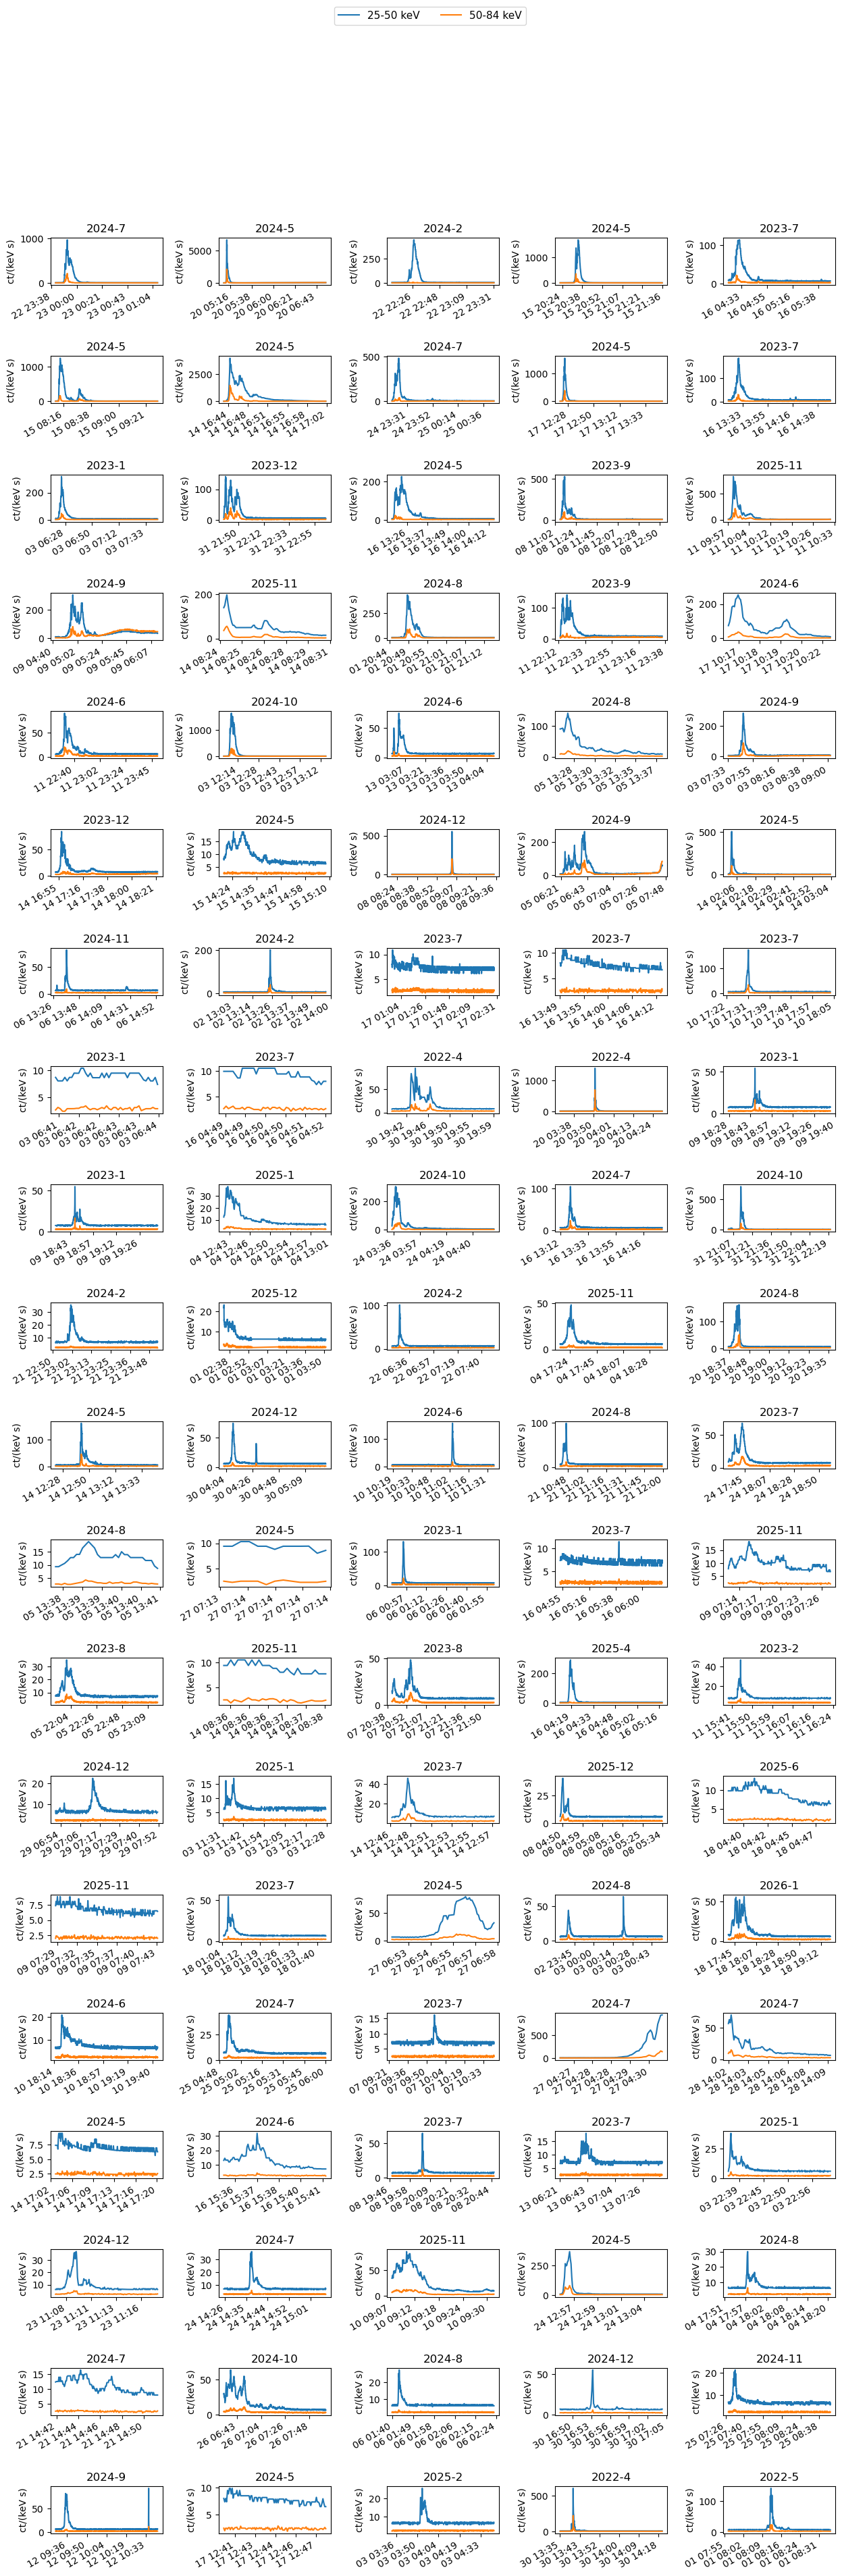

In [8]:

# ax.set_yscale('linear')
# ax.set_ylabel('ct/(keV s)')


fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
axes = axes.flatten()
i=0
for ind in top100.index:
    ax=axes[i]
    plot_flare_modified(top100['start_UTC'].loc[ind], top100['end_UTC'].loc[ind])
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    date_form = DateFormatter("%d %H:%M")
    ax.xaxis.set_major_formatter(date_form)
    
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=1.5)
fig.subplots_adjust(wspace=0.5)

plt.show()
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_quicklook_data.png", bbox_inches='tight')

In [9]:
top100['flare_id']

17678    2407222356
16121    2405200514
12921    2402222230
15873    2405152036
8972     2307160433
            ...    
19855    2409120937
15986    2405171242
24906    2502030356
2083     2204301342
2130     2205010814
Name: flare_id, Length: 100, dtype: int64

In [10]:
flare1 = top100.loc[17678]
print(flare1['start_UTC'], flare1['end_UTC'])

2024-07-22T23:41:53.133 2024-07-23T01:08:49.142


In [11]:
flare1['flare_id']

np.int64(2407222356)

In [12]:
flare1['cpd_filename']

'./pixel_data/solo_L1_stix-sci-xray-cpd_20240722T232050-20240723T001432_V02_2407227814-56169.fits'

In [13]:
sci_query = Fido.search(a.Time(flare1['start_UTC'], flare1['end_UTC']), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-07-22T22:59:59.000,2024-07-23T05:00:03.000,STIX,L1,SCI,sci-xray-cpd,V02,2407226158
2024-07-22T23:20:50.000,2024-07-23T00:14:32.000,STIX,L1,SCI,sci-xray-cpd,V02,2407227814
2024-07-22T21:25:14.000,2024-07-23T03:29:59.000,STIX,L1,SCI,sci-xray-spec,V04,2407221990
2024-07-23T00:14:17.000,2024-07-23T01:19:30.000,STIX,L1,SCI,sci-xray-cpd,V02,2407236589


In [14]:
sci_files = Fido.fetch(sci_query[0][[1,2]])
sci_files = sorted(sci_files)
sci_files

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

['C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-cpd_20240722T232050-20240723T001432_V02_2407227814-56169.fits',
 'C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-spec_20240722T212514-20240723T032959_V04_2407221990-58981.fits']

In [15]:
from stixpy.product import Product
cpd1_1 = Product(sci_files[0])
cpd1_2 = Product(sci_files[1])

In [16]:
cpd1_1.energies

channel,e_low,e_high
,keV,keV
uint8,float32,float32
0,4.0,5.0
1,5.0,6.0
2,6.0,7.0
3,7.0,8.0
4,8.0,9.0
5,9.0,10.0
6,10.0,11.0
7,11.0,12.0


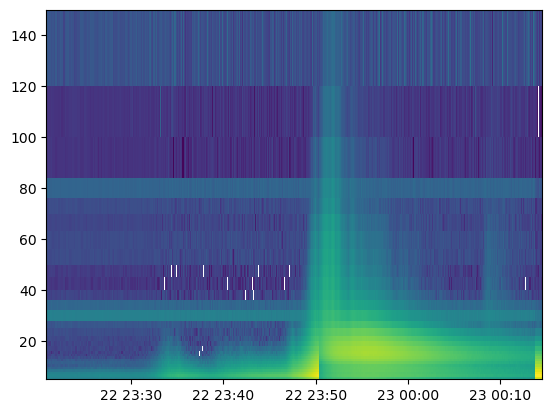

In [17]:
cpd1_1.plot_spectrogram()

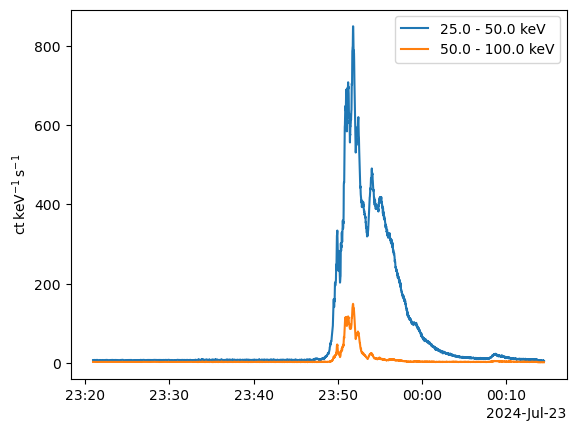

In [18]:
cpd1_1.plot_timeseries(energy_indices=[[16, 21], [22, 27]])
plt.legend()
plt.yscale('linear')

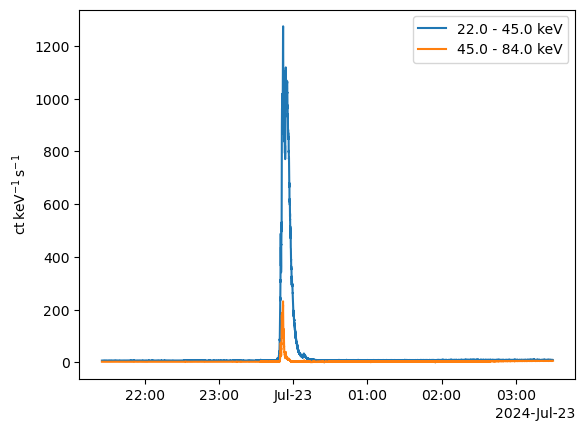

In [19]:
cpd1_2.plot_timeseries(energy_indices=[[16, 21], [22, 27]])
plt.legend()
plt.yscale('linear')

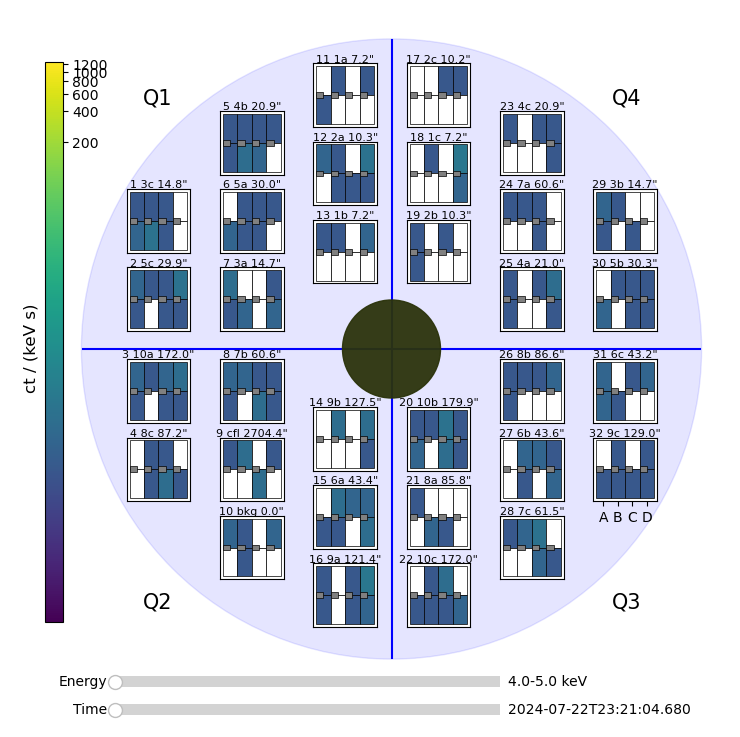

In [20]:
cpd1_1.plot_pixels()

In [21]:
cpd1_2.energies["e_low"]>6*u.keV

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [22]:
flare2 = top100.loc[16121]
print(flare2['start_UTC'], flare2['end_UTC'])

2024-05-20T05:10:08.351 2024-05-20T06:52:32.361


In [23]:
sci_query = Fido.search(a.Time(flare2['start_UTC'], flare2['end_UTC']), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
sci_query['stix'].filter_for_latest_version()
sci_query

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2024-05-20T04:45:00.000,2024-05-20T10:45:00.000,STIX,L1,SCI,sci-xray-cpd,V02,2405209951
2024-05-20T04:57:02.000,2024-05-20T05:38:05.000,STIX,L1,SCI,sci-xray-cpd,V02,2405203899
2024-05-20T05:07:11.000,2024-05-20T05:24:48.000,STIX,L1,SCI,sci-xray-cpd,V02,2405207131
2024-05-20T02:29:59.000,2024-05-20T08:34:59.000,STIX,L1,SCI,sci-xray-spec,V04,2405209781


In [24]:
flare2['cpd_filename']

'./pixel_data/solo_L1_stix-sci-xray-cpd_20240520T044500-20240520T104500_V02_2405209951-50924.fits'

In [25]:
flare2['flare_id']

np.int64(2405200514)

In [26]:
sci_files = Fido.fetch(sci_query[0][0])
sci_files = sorted(sci_files)
sci_files

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-cpd_20240520T044500-20240520T104500_V02_2405209951-50924.fits']

In [27]:
cpd2 = Product(sci_files)
cpd2

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x2571cb596d0>
    Start: 2024-05-20 04:45:00
    End:   2024-05-20 10:45:00
    Center:2024-05-20 07:45:00
    Duration:0.2500023148148148 days or
           6.000055555555555 hours or
           360.0033333333333 minutes or
           21600.199999999997 seconds
    DetectorMasks
    [0...76]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...76]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32]

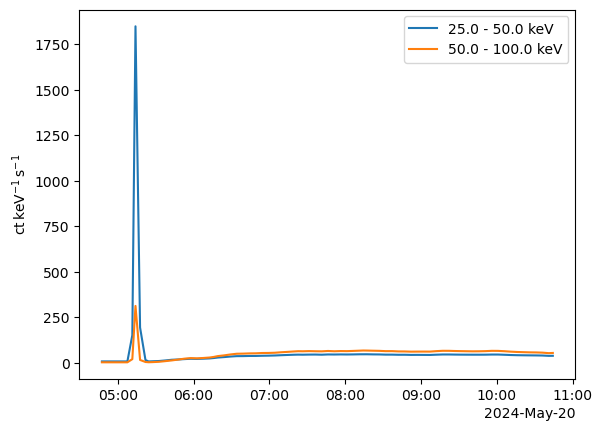

In [28]:
cpd2.plot_timeseries(energy_indices=[[16, 21], [22, 27]])
plt.legend()
plt.yscale('linear')

In [29]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [30]:
def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [31]:
cpd1_2.energies['e_low'][len(cpd1_2.energies['e_low'])-1]

<Quantity 150. keV>

In [32]:
energy_indices = get_energy_indices(cpd1_2.energies, energy_ranges)
counts, errors, times, timedeltas, energies = cpd1_2.get_data(detector_indices=[[0, 31]],
                                                              pixel_indices=[[0, 11]],
                                                              energy_indices=energy_indices,)
timedeltas

<Quantity [[[[20. ]]],


           [[[20. ]]],


           [[[20. ]]],


           ...,


           [[[ 4.7]]],


           [[[ 4.7]]],


           [[[ 4.6]]]] s>

In [33]:
largeflare_sci_df = get_stix_df(cpd1_2, energy_ranges)
largeflare_sci_df

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-07-22 21:25:24.318,6.036000,1.762000
2024-07-22 21:25:44.318,6.108000,1.826000
2024-07-22 21:26:04.318,6.476000,1.650000
2024-07-22 21:26:24.318,6.648000,1.670000
2024-07-22 21:26:44.318,6.652000,1.682000
...,...,...
2024-07-23 03:29:38.668,8.355556,5.111111
2024-07-23 03:29:43.318,7.683333,5.025000
2024-07-23 03:29:48.068,8.476596,4.791489
2024-07-23 03:29:52.768,8.765957,5.336170


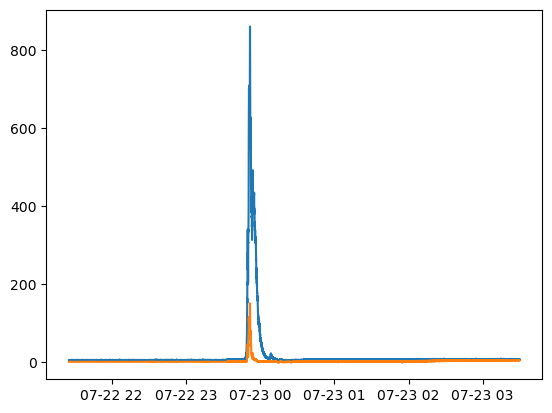

In [34]:
plt.plot(largeflare_sci_df.index, largeflare_sci_df['25.0 keV-50.0 keV'])
plt.plot(largeflare_sci_df.index, largeflare_sci_df['50.0 keV-100.0 keV'])

In [35]:
len(largeflare_sci_df.columns)

2

In [36]:
def plot_flare_modified_sci(sci_df, flare_start=None, flare_end=None):
    if flare_start!=None and flare_end!=None:
        flare_start_obj = parse_time(flare_start)
    
        flare_end_obj = parse_time(flare_end)
        
        plot_df = sci_df.truncate(flare_start_obj.datetime, flare_end_obj.datetime)
    else:
        plot_df = sci_df.copy()
        
    plot_df.index = parse_time(plot_df.index).datetime

    #plotting lightcurves
    fig, ax = plt.subplots()
    ax.set_yscale('linear')
    ax.set_ylabel('ct/(keV s)')
    
    for n in range(len(plot_df.columns)):
        ax.plot(ax=ax, y=plot_df.columns[n], label=plot_df.columns[n], legend=None)

    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels, loc='upper right', fontsize='small')
    if flare_start!=None and flare_end!=None:
        plt.title(f"{flare_start_obj.datetime.year}-{flare_end_obj.datetime.month}")
        

TypeError: plot() got an unexpected keyword argument 'y'

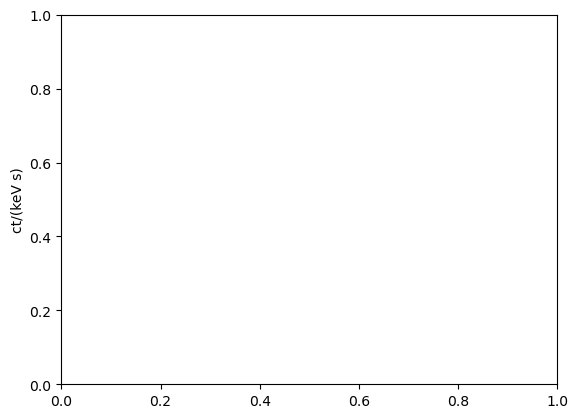

In [37]:
plot_flare_modified_sci(largeflare_sci_df, flare1['start_UTC'], flare1['end_UTC'])

In [38]:
df_list=[]
indices=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    data=False
    badrange=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=start and sci_query[0][n][1].datetime>=end:
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
            data=True
            if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
                badrange=True
        if data and not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [39]:
len(df_list)

60

In [40]:
len(indices)

60

In [41]:
listind100 = top100.index.tolist()
diff = set(listind100)-set(indices)
diff

{6201,
 8717,
 8745,
 10252,
 12890,
 12903,
 15754,
 15798,
 15799,
 15856,
 15873,
 16441,
 16442,
 16647,
 16662,
 16837,
 16865,
 17486,
 17633,
 17750,
 18238,
 18320,
 19855,
 21278,
 22177,
 22261,
 22548,
 22906,
 23889,
 24133,
 24215,
 24342,
 24354,
 24906,
 26858,
 30475,
 30476,
 30637,
 30638,
 31028}

In [42]:
indices_array = np.array([indices])
np.where(indices_array==17935)[1][0]

np.int64(50)

In [44]:
indices_array

array([[17678, 16121, 12921,  8972, 15844, 17775, 15985,  9007,  5513,
        11949, 15918, 10165, 30536, 19665, 16710, 16752, 18432, 19400,
        11730, 23607, 19491, 12385,  9046,  9008,  8812,  5514,  8973,
         2102,  2060,  5639,  5640, 24372, 30855, 30331, 18944, 15783,
        24196, 18991,  9370, 18433,  5547,  8974,  9668,  9743,  8927,
        27709,  9100, 31580, 17787, 17859, 17935,  8890, 30496, 16352,
        18407, 18455, 23346, 15986,  2083,  2130]])

In [45]:
def plot_flare_modified_sci_multiple(sci_df):

    start = parse_time(top100['start_UTC'].loc[indices[i]]).datetime

    end = parse_time(top100['end_UTC'].loc[indices[i]]).datetime
    
    plot_df = sci_df.truncate(start, end)
        
    plot_df.index = parse_time(plot_df.index).datetime
    
    for n in range(len(plot_df.columns)):
        ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])

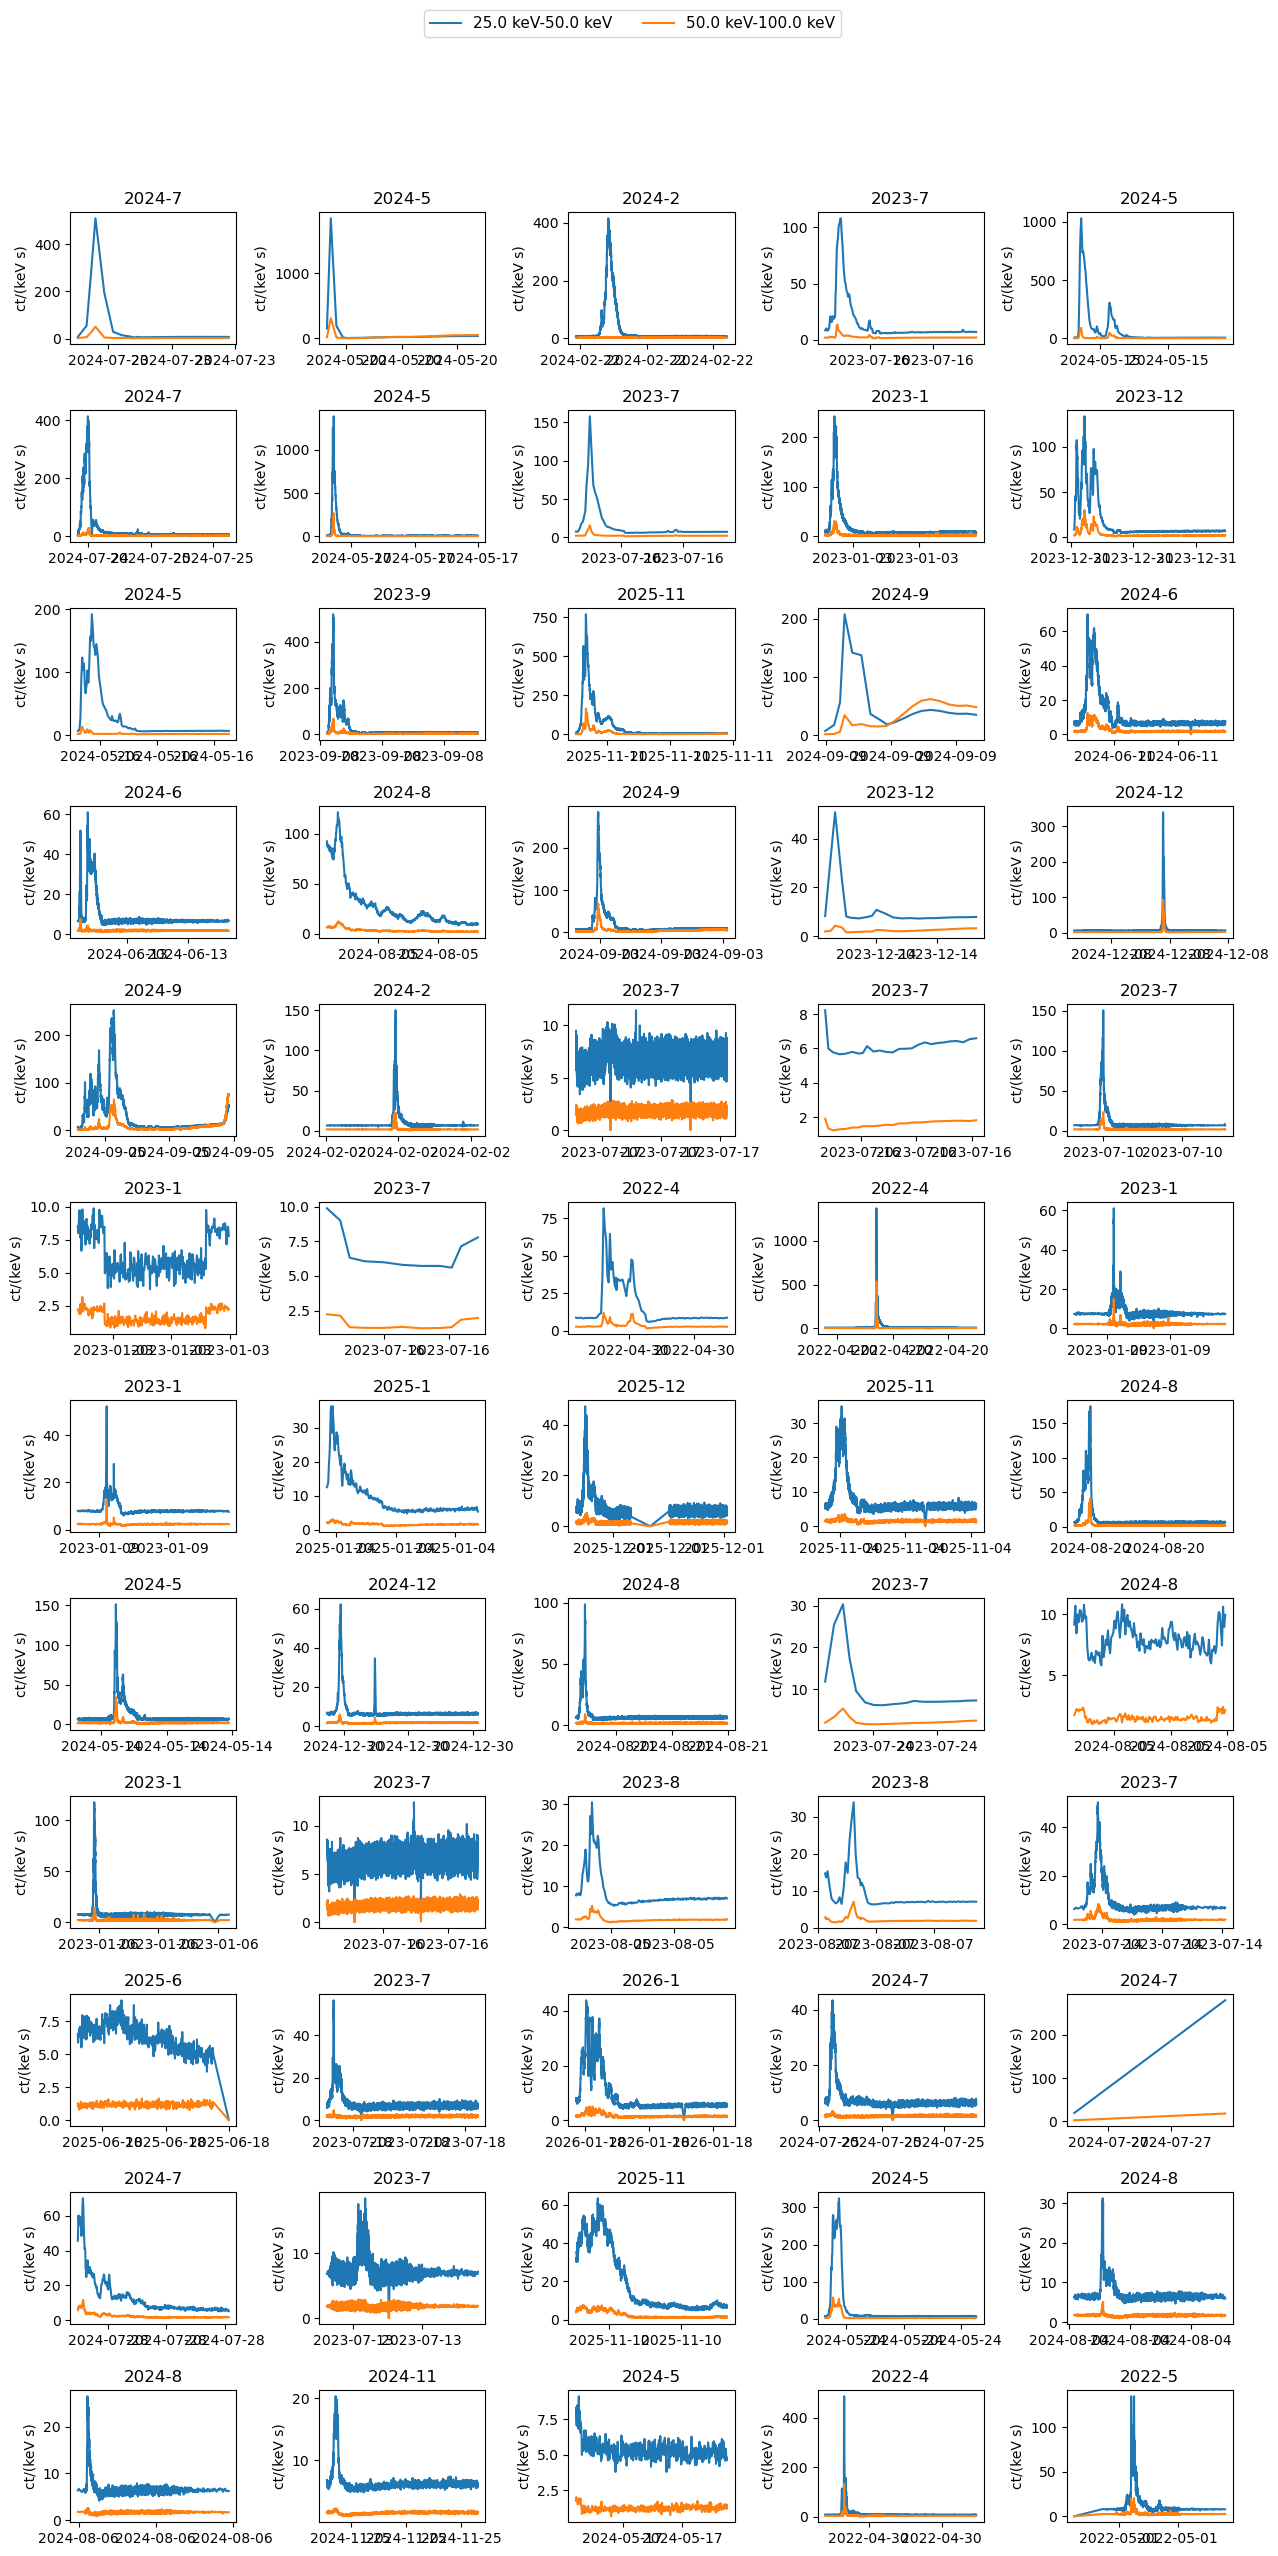

In [46]:
fig, axes = plt.subplots(nrows=12, ncols=5, figsize=(15, 30))
axes = axes.flatten()
i=0
for df in df_list:
    ax=axes[i]
    plot_flare_modified_sci_multiple(df)
    ax.set_ylabel('ct/(keV s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[indices[i]]).datetime.year}-{parse_time(top100['start_UTC'].loc[indices[i]]).datetime.month}")
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=0.5)
fig.subplots_adjust(wspace=0.5)

plt.show()

In [47]:
print(top100['start_UTC'].loc[6201], top100['end_UTC'].loc[6201])

2023-02-11T15:40:07.629 2023-02-11T16:23:39.633


In [48]:
sci_query_6201 = Fido.search(a.Time(top100['start_UTC'].loc[6201], 
                                   top100['end_UTC'].loc[6201]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
sci_query_6201['stix'].filter_for_latest_version()
sci_query_6201

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-02-11T13:15:52.000,2023-02-11T15:40:15.000,STIX,L1,SCI,sci-xray-cpd,V02,2302112410
2023-02-11T15:31:10.000,2023-02-11T16:20:14.000,STIX,L1,SCI,sci-xray-cpd,V02,2302118450
2023-02-11T15:38:43.000,2023-02-11T15:52:03.000,STIX,L1,SCI,sci-xray-cpd,V02,2302116868
2023-02-11T16:16:07.000,2023-02-11T17:55:23.000,STIX,L1,SCI,sci-xray-cpd,V02,2302115819
2023-02-11T10:15:02.000,2023-02-11T16:20:02.000,STIX,L1,SCI,sci-xray-spec,V04,2302112350
2023-02-11T16:15:04.000,2023-02-11T22:20:03.000,STIX,L1,SCI,sci-xray-spec,V04,2302114194


In [49]:
start_6201 = parse_time(top100['start_UTC'].loc[6201]).datetime
end_6201 = parse_time(top100['end_UTC'].loc[6201]).datetime

In [50]:
get_best_file_tr(start_6201, end_6201, sci_query_6201)

NameError: name 'get_best_file_tr' is not defined

In [51]:
df_list[np.where(indices_array==top100.index[5])[1][0]]

,25.0 keV-50.0 keV,50.0 keV-100.0 keV
2024-05-15 06:51:15.178,6.878899,2.062385
2024-05-15 06:51:38.078,6.823333,2.170000
2024-05-15 06:52:01.828,6.845957,2.142979
2024-05-15 06:52:25.378,6.971429,2.105042
2024-05-15 06:52:50.228,6.719066,2.021012
...,...,...
2024-05-15 12:34:14.178,6.856000,1.928000
2024-05-15 12:34:34.178,6.828000,2.073000
2024-05-15 12:34:54.178,6.802000,2.054000
2024-05-15 12:35:14.178,6.642000,1.973000


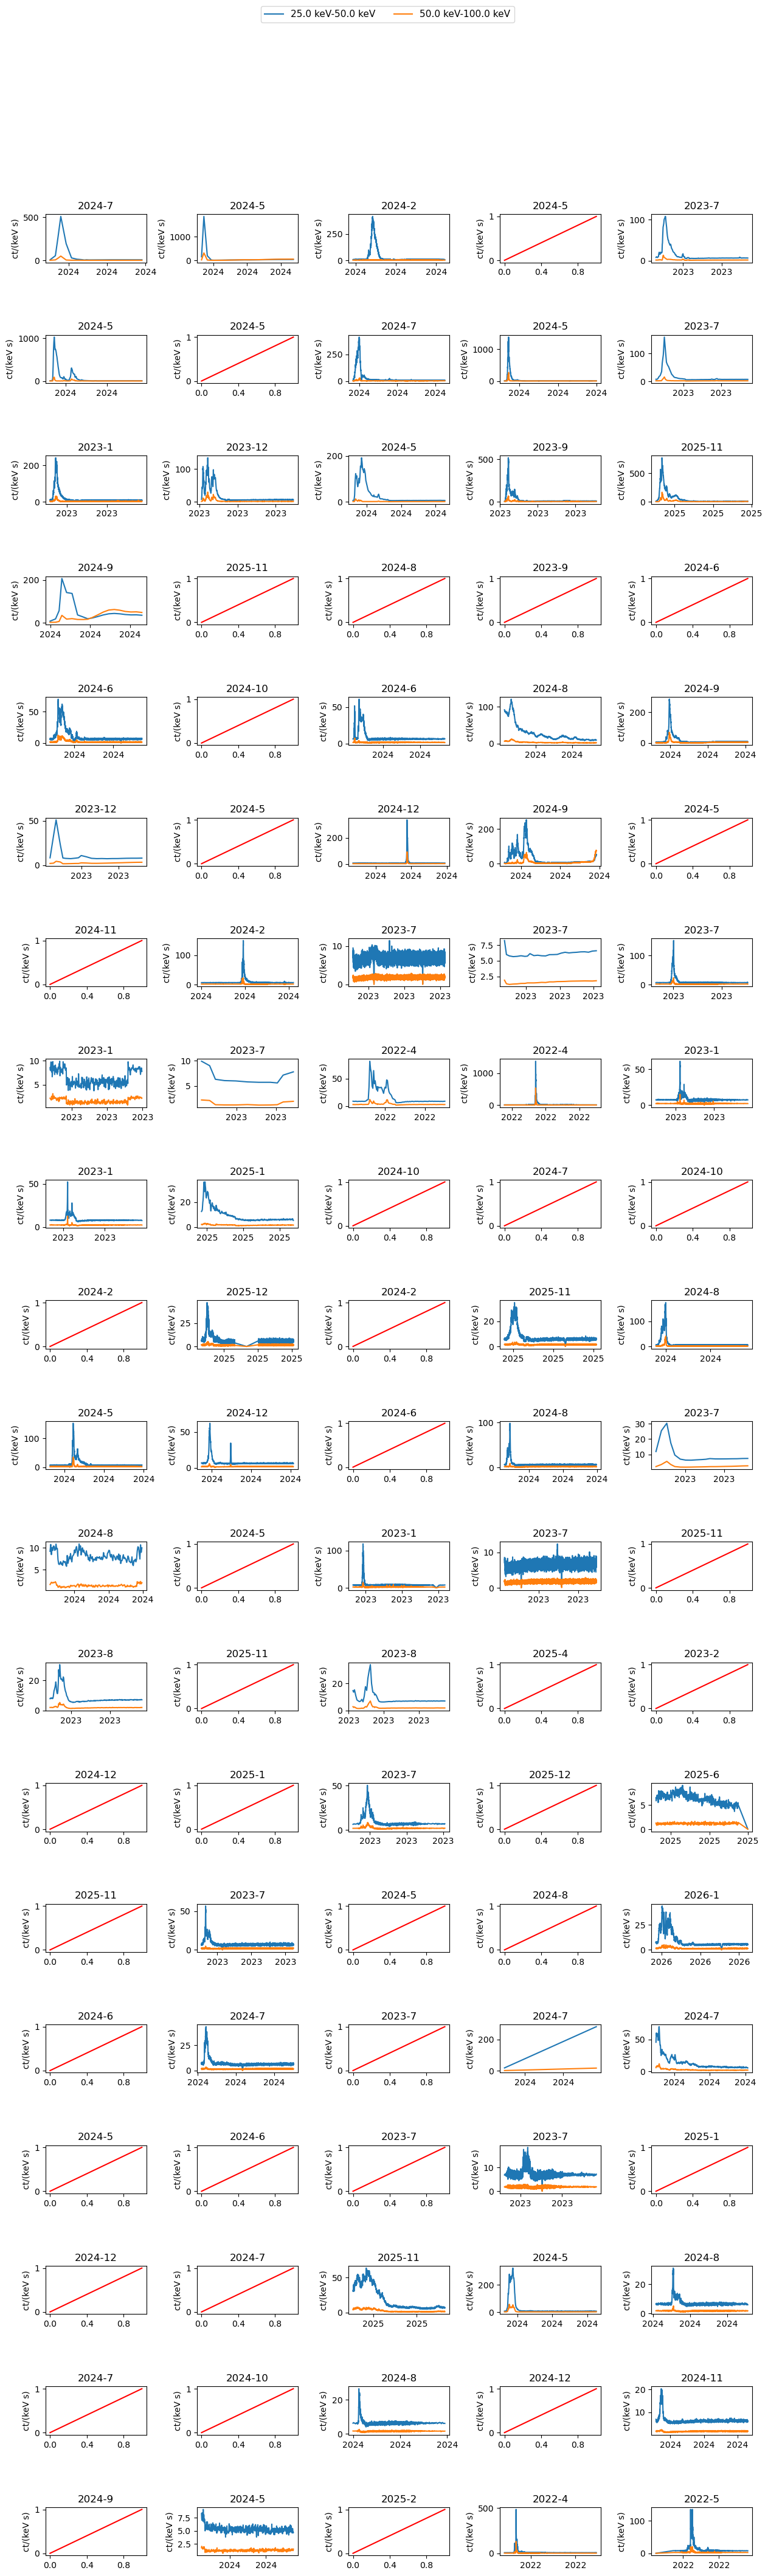

In [52]:
fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
axes = axes.flatten()
i=0
for ind in top100.index:
    ax=axes[i]
    ax.set_ylabel('ct/(keV s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    if ind in indices:
        sci_df = df_list[np.where(indices_array==ind)[1][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime
        end = parse_time(top100['end_UTC'].loc[ind]).datetime
        
        plot_df = sci_df.truncate(start, end)
            
        plot_df.index = parse_time(plot_df.index).datetime
        
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    else:
        ax.plot([0,1],[0,1], color='red')
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=1.5)
fig.subplots_adjust(wspace=0.5)

plt.show
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_first_draft.png", bbox_inches='tight')

In [53]:
def get_best_file_tr(start, end, sci_query):
    best_file_tr = None
    max_overlap = dt.timedelta(0)

    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        
        if overlap > max_overlap:
            max_overlap = overlap
            best_file_tr = sci_query[0][n]

    return best_file_tr


In [54]:
df_list1=[]
indices1=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    badrange=False
    sci_files = Fido.fetch(get_best_file_tr(start, end, sci_query))
    sci_data = Product(sci_files)
    
    if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
        badrange=True
        
    if not badrange:
        sci_df = get_stix_df(sci_data, energy_ranges)
        df_list1.append(sci_df)
        indices1.append(ind)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [55]:
len(df_list1)

64

In [56]:
diff1 = set(listind100)-set(indices1)
diff1

{8717,
 12890,
 12903,
 15754,
 15798,
 15799,
 15873,
 16441,
 16442,
 16647,
 16662,
 16837,
 16865,
 17486,
 17633,
 17750,
 18238,
 18320,
 19855,
 21278,
 22177,
 22261,
 22548,
 22906,
 23889,
 24133,
 24215,
 24342,
 24354,
 24906,
 26858,
 30475,
 30476,
 30637,
 30638,
 31028}

In [57]:
sci_query_8717 = Fido.search(a.Time(top100['start_UTC'].loc[8717], 
                                   top100['end_UTC'].loc[8717]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
sci_query_8717['stix'].filter_for_latest_version()
sci_query_8717

Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str3,str13,str3,int64
2023-07-07T09:18:12.000,2023-07-07T10:47:31.000,STIX,L1,SCI,sci-xray-cpd,V02,2307070862
2023-07-07T09:53:33.000,2023-07-07T09:58:27.000,STIX,L1,SCI,sci-xray-cpd,V02,2307076470
2023-07-07T08:30:04.000,2023-07-07T14:35:03.000,STIX,L1,SCI,sci-xray-spec,V04,2307072124


In [58]:
print(top100['start_UTC'].loc[8717], top100['end_UTC'].loc[8717])

2023-07-07T09:23:55.923 2023-07-07T10:41:31.931


In [59]:
sci_files_8717 = Fido.fetch(sci_query_8717)
sci_files_8717 = sorted(sci_files_8717)
sci_files_8717

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

['C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-cpd_20230707T091812-20230707T104731_V02_2307070862-63463.fits',
 'C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-cpd_20230707T095333-20230707T095827_V02_2307076470-63571.fits',
 'C:\\Users\\derva\\sunpy\\data\\solo_L1_stix-sci-xray-spec_20230707T083004-20230707T143503_V04_2307072124-58295.fits']

In [60]:
data_8717_1 = Product(sci_files_8717[0])
data_8717_2 = Product(sci_files_8717[1])
data_8717_3 = Product(sci_files_8717[2])

In [61]:
data_8717_1.energies

channel,e_low,e_high
,keV,keV
uint8,float32,float32
0,4.0,5.0
1,5.0,6.0
2,6.0,7.0
3,7.0,8.0
4,8.0,9.0
5,9.0,10.0
6,10.0,11.0
7,11.0,12.0


In [62]:
data_8717_2.energies

channel,e_low,e_high
,keV,keV
uint8,float32,float32
0,4.0,5.0
1,5.0,6.0
2,6.0,7.0
3,7.0,8.0
4,8.0,9.0
5,9.0,10.0
6,10.0,11.0
7,11.0,12.0


In [63]:
data_8717_3.energies

channel,e_low,e_high
,keV,keV
uint8,float32,float32
0,0.0,4.0
1,4.0,5.0
2,5.0,6.0
3,6.0,7.0
4,7.0,8.0
5,8.0,9.0
6,9.0,10.0
7,10.0,11.0


In [64]:
def rank_overlaps(start, end, sci_query):
    overlaps=[]
    for n in range(len(sci_query[0])):
        latest_start = max(start, sci_query[0][n][0].datetime)
        earliest_end = min(end, sci_query[0][n][1].datetime)
        
        overlap = earliest_end - latest_start
        overlaps.append((overlap.total_seconds(), n))
        
    return np.array(sorted(overlaps, key=lambda x: x[0], reverse=True))

In [65]:
x =rank_overlaps(parse_time(top100['start_UTC'].loc[8717]).datetime, parse_time(top100['end_UTC'].loc[8717]).datetime, sci_query_8717)
x

array([[4.656008e+03, 0.000000e+00],
       [4.656008e+03, 2.000000e+00],
       [2.940000e+02, 1.000000e+00]])

In [66]:
x[:,1]

array([0., 2., 1.])

In [67]:
df_list2=[]
indices2=[]
for ind in top100.index:
    sci_query = Fido.search(a.Time(top100['start_UTC'].loc[ind], 
                                   top100['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
    sci_query['stix'].filter_for_latest_version()

    start = parse_time(top100['start_UTC'].loc[ind]).datetime
    end = parse_time(top100['end_UTC'].loc[ind]).datetime

    overlaps_ranked = rank_overlaps(start, end, sci_query)
    
    for index in overlaps_ranked[:,1]:
        badrange=False
        sci_files = Fido.fetch(sci_query[0][int(index)])
        sci_data = Product(sci_files)
    
        if sci_data.energies["e_high"][len(sci_data.energies["e_high"])-1]<100*u.keV or sci_data.energies["e_low"][0]>25*u.keV:
            badrange=True
        
        if not badrange:
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list2.append(sci_df)
            indices2.append(ind)
            break

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [68]:
len(df_list2)

100

In [69]:
diff2 = set(listind100)-set(indices2)
diff2 

set()

In [70]:
indices2_array = np.array([indices2])

In [71]:
df_list2[0].index

DatetimeIndex(['2024-07-22 23:02:33.828000', '2024-07-22 23:07:38.178000',
               '2024-07-22 23:12:38.928000', '2024-07-22 23:17:41.178000',
               '2024-07-22 23:22:43.928000', '2024-07-22 23:27:48.428000',
               '2024-07-22 23:32:52.328000', '2024-07-22 23:37:52.778000',
               '2024-07-22 23:42:53.028000', '2024-07-22 23:47:51.528000',
               '2024-07-22 23:50:21.528000', '2024-07-22 23:52:53.028000',
               '2024-07-22 23:57:53.028000', '2024-07-23 00:02:53.028000',
               '2024-07-23 00:07:53.028000', '2024-07-23 00:12:03.528000',
               '2024-07-23 00:14:33.528000', '2024-07-23 00:15:33.528000',
               '2024-07-23 00:16:44.178000', '2024-07-23 00:19:03.878000',
               '2024-07-23 00:22:53.428000', '2024-07-23 00:27:53.428000',
               '2024-07-23 00:30:41.428000', '2024-07-23 00:33:29.428000',
               '2024-07-23 00:38:29.428000', '2024-07-23 00:43:29.428000',
               '2024-07-2

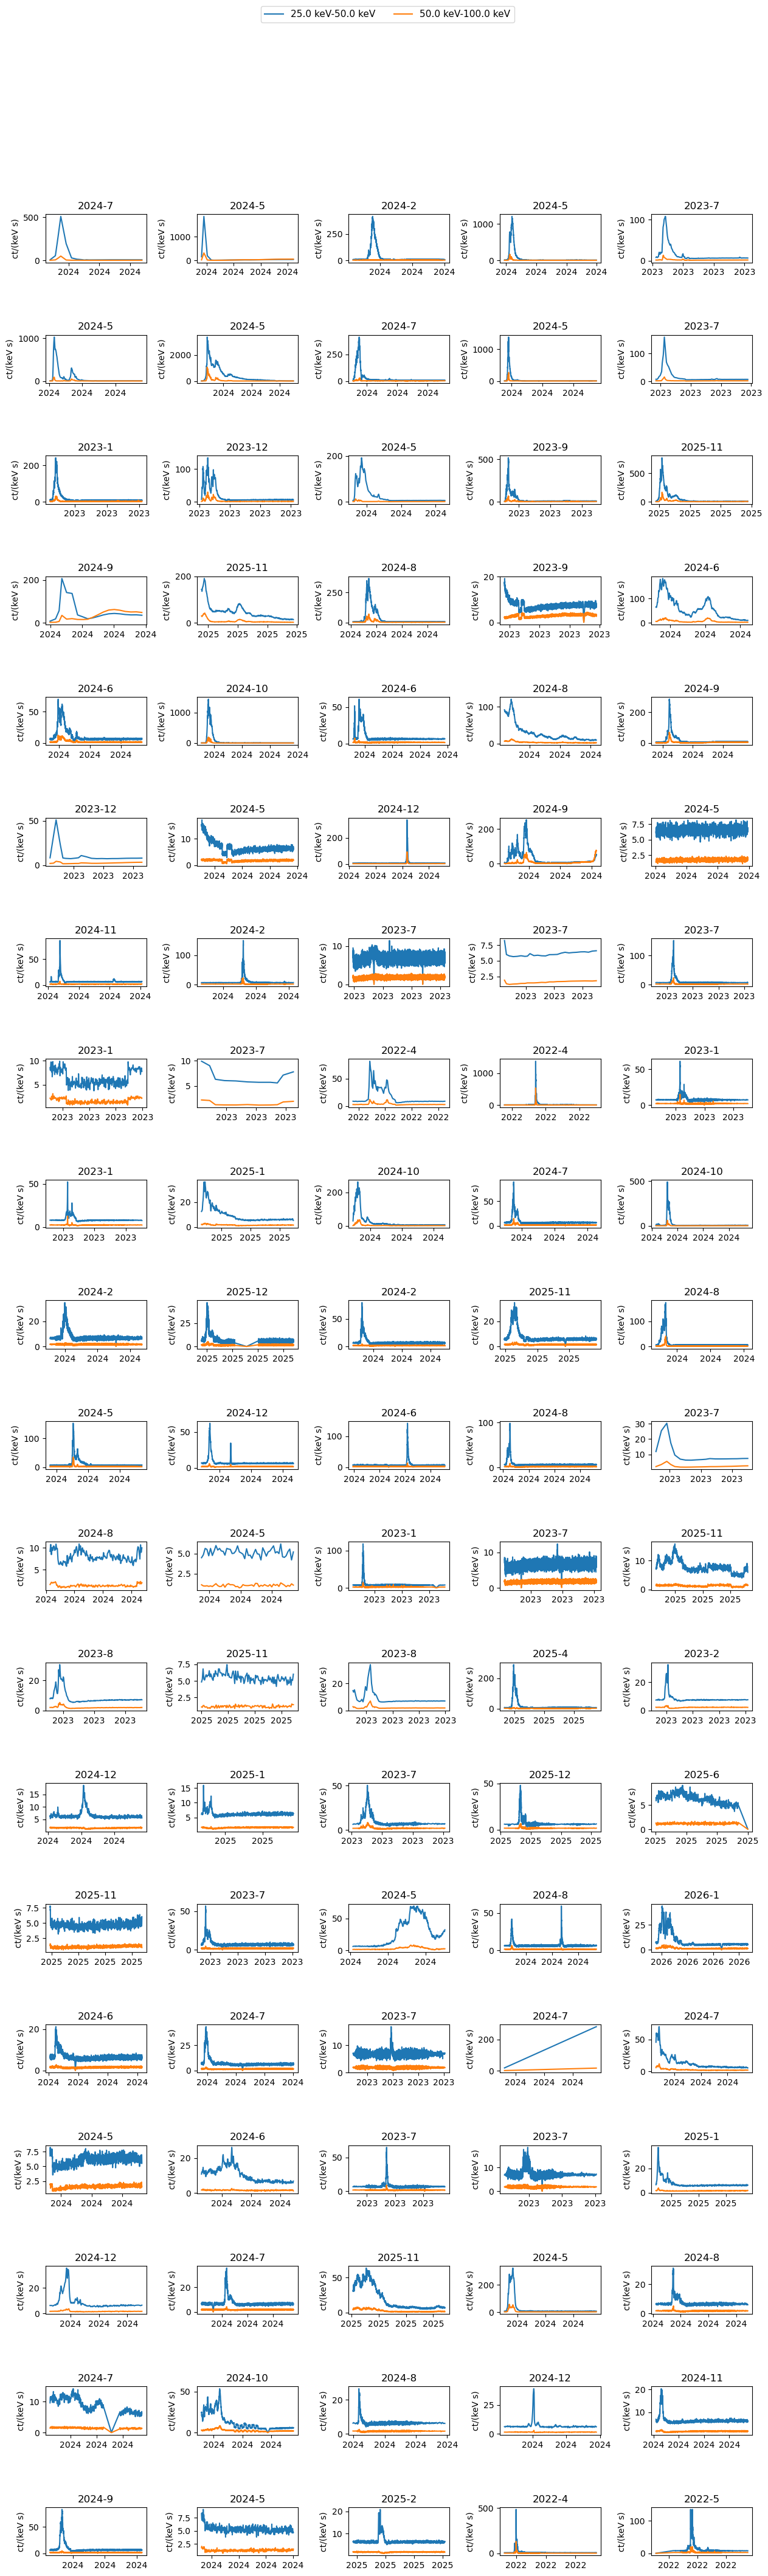

In [72]:
fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
axes = axes.flatten()
i=0
for ind in top100.index:
    ax=axes[i]
    ax.set_ylabel('ct/(keV s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    if ind in indices2:
        sci_df = df_list2[np.where(indices2_array==ind)[1][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime
        end = parse_time(top100['end_UTC'].loc[ind]).datetime
        
        plot_df = sci_df.truncate(start, end)
            
        plot_df.index = parse_time(plot_df.index).datetime
        
        for n in range(len(plot_df.columns)):
            ax.plot(plot_df.index, plot_df[plot_df.columns[n]], label=plot_df.columns[n])
    else:
        ax.plot([0,1],[0,1], color='red')

    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=1.5)
fig.subplots_adjust(wspace=0.5)

plt.show()
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_full.png", bbox_inches='tight')

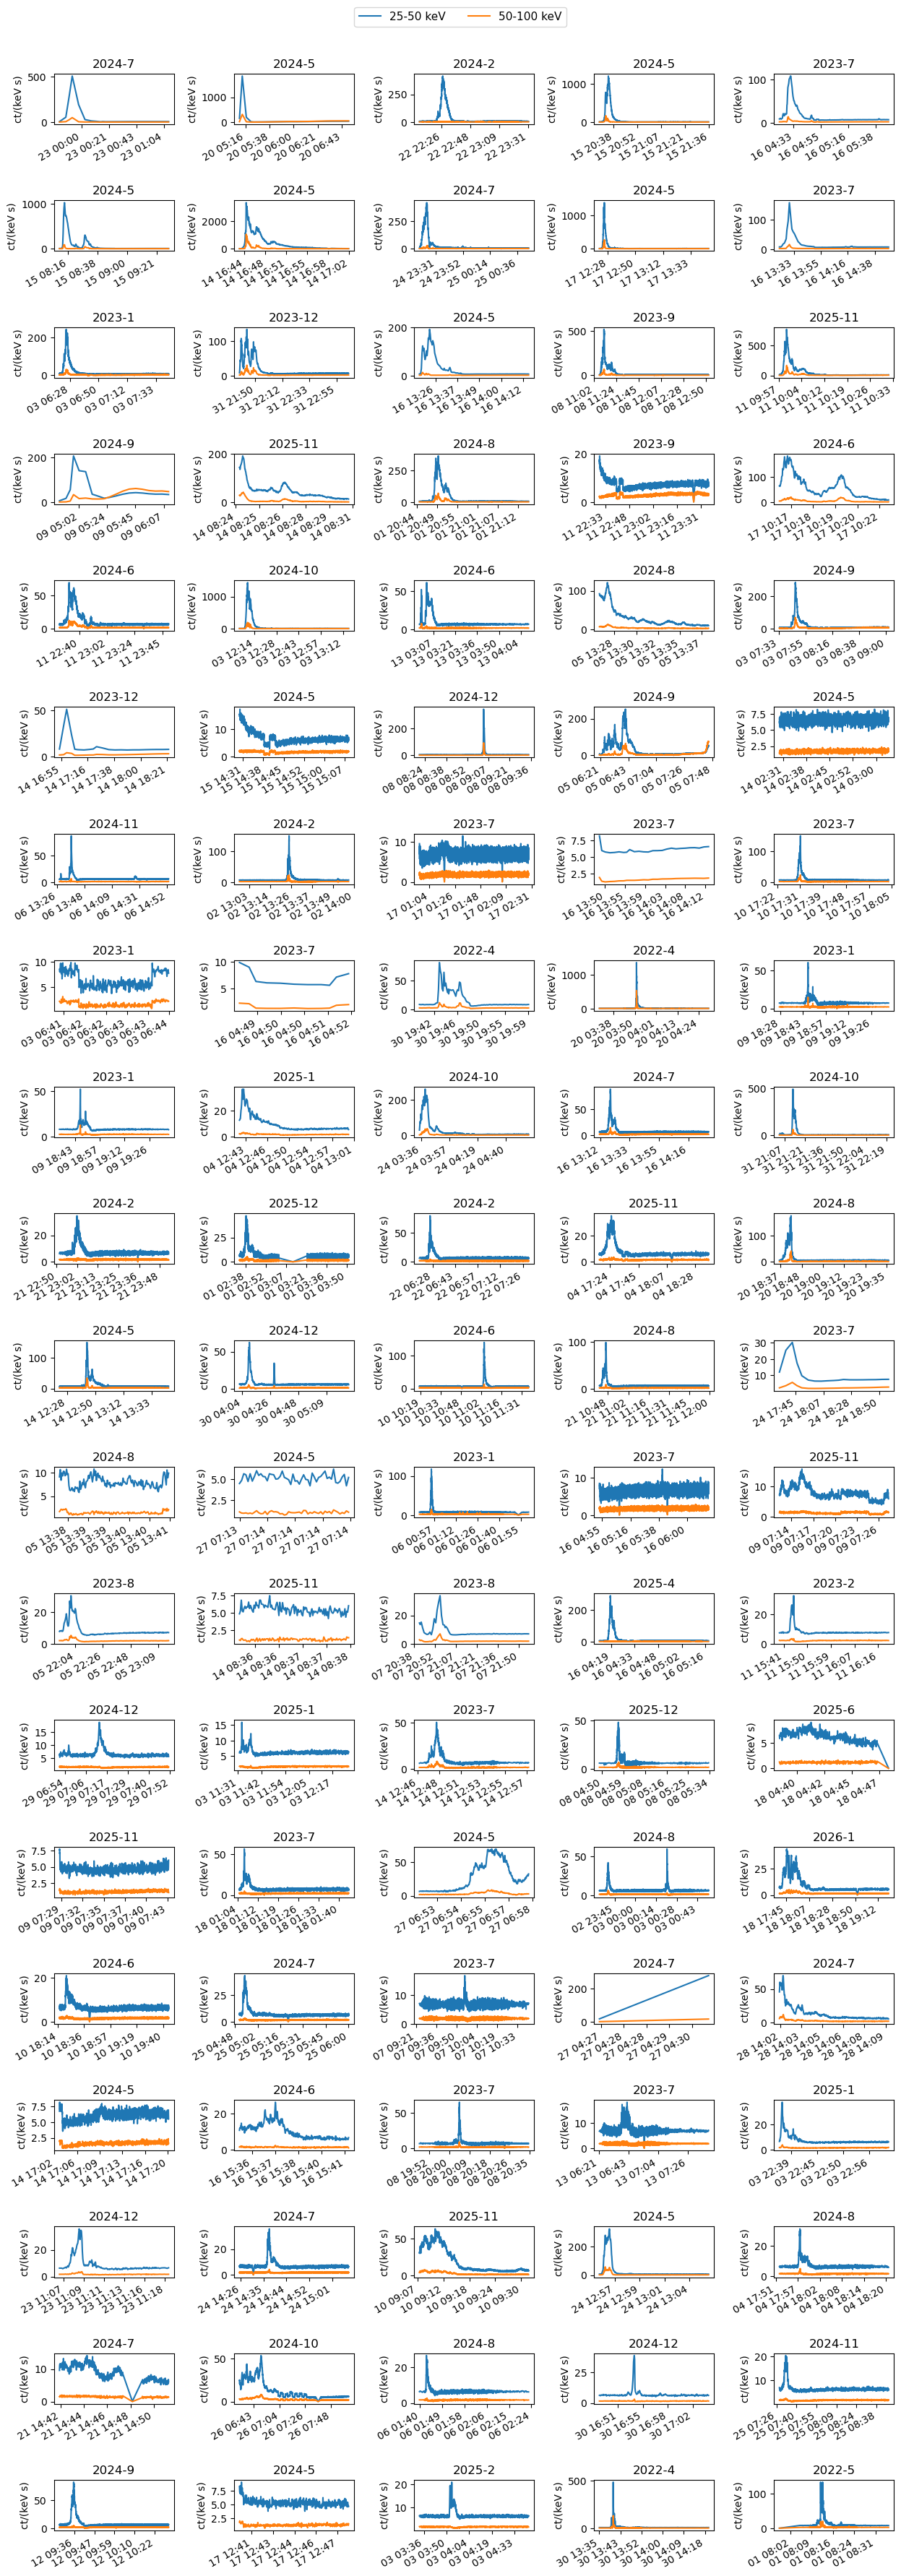

In [73]:
fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
axes = axes.flatten()
i=0
for ind in top100.index:
    ax=axes[i]
    ax.set_ylabel('ct/(keV s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    if ind in indices2:
        sci_df = df_list2[np.where(indices2_array==ind)[1][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime
        end = parse_time(top100['end_UTC'].loc[ind]).datetime
        
        plot_df = sci_df.truncate(start, end)
            
        plot_df.index = parse_time(plot_df.index).datetime
        
        plot_df.plot(ax=ax, y='25.0 keV-50.0 keV', label='25-50 keV', legend=None)
        plot_df.plot(ax=ax, y='50.0 keV-100.0 keV', label='50-100 keV', legend=None)
        
    else:
        ax.plot([0,1],[0,1], color='red')

    date_form = DateFormatter("%d %H:%M")
    ax.xaxis.set_major_formatter(date_form)
    
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=1.5)
fig.subplots_adjust(wspace=0.5)

plt.show()
fig.savefig("C:/Users/derva/OneDrive/Documents/DIAS/solar-orbiter-flare-statistics/figures/top_100_flares_science_data_full.png", bbox_inches='tight')

In [74]:
# times = times
    
# energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]

# counts_reshaped = counts[:, 0, 0, :]

# counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)

In [75]:
from scipy.signal import find_peaks, peak_widths, savgol_filter

In [76]:
flare1_df = df_list2[0]

In [77]:
flare1_stat_df = flare1_df.copy()
peaks, properties = find_peaks(flare1_stat_df['25.0 keV-50.0 keV'],distance=10, prominence=10)
peaks = peaks.tolist()
peaks

[11]

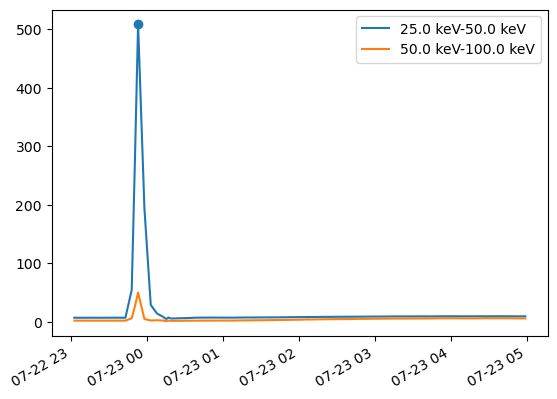

In [78]:
flare1_df.plot()
plt.scatter(flare1_stat_df.index[peaks], flare1_stat_df['25.0 keV-50.0 keV'].iloc[peaks])

In [79]:
flare3_df = df_list2[2]

In [80]:
peaks3, properties3 = find_peaks(flare3_df['25.0 keV-50.0 keV'],distance=100, prominence=50)
peaks3

array([6744, 7182])

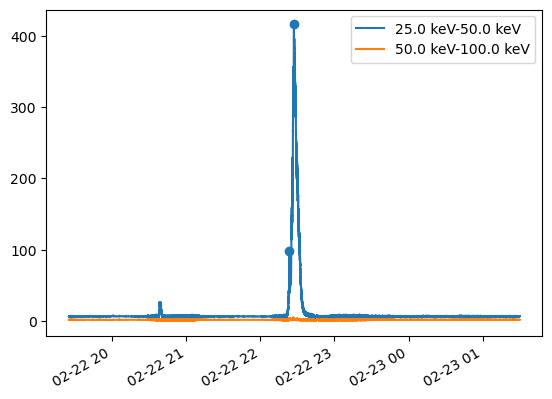

In [81]:
flare3_df.plot()
plt.scatter(flare3_df.index[peaks3], flare3_df['25.0 keV-50.0 keV'].iloc[peaks3])

In [82]:
flare3_stat_df = flare3_df.copy()
flare3_stat_df['25.0 keV-50.0 keV'] = savgol_filter(flare3_stat_df['25.0 keV-50.0 keV'], window_length=11, polyorder=3)

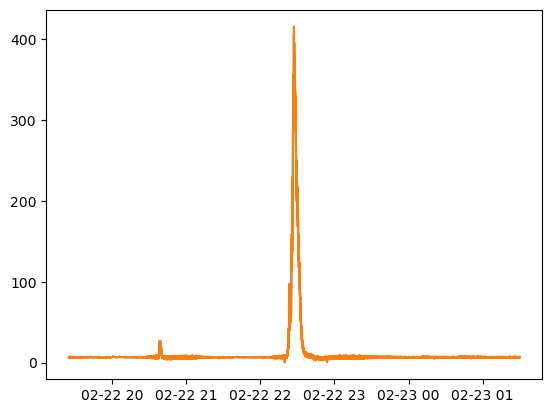

In [83]:
plt.plot(flare3_stat_df.index, flare3_stat_df['25.0 keV-50.0 keV'])
plt.plot(flare3_df.index, flare3_df['25.0 keV-50.0 keV'])

In [84]:
flare12_df = df_list[11]

In [85]:
peaks12, properties12 = find_peaks(flare12_df['25.0 keV-50.0 keV'],distance=50, prominence=50)
peaks12

array([ 697,  767,  820, 1112, 1257])

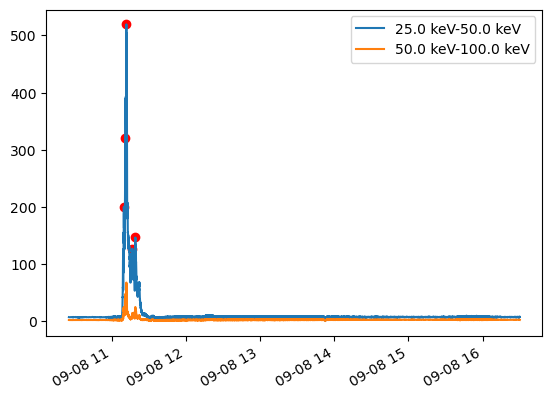

In [86]:
flare12_df.plot()
plt.scatter(flare12_df.index[peaks12], flare12_df['25.0 keV-50.0 keV'].iloc[peaks12], color='red')

In [87]:
peak_locs = [[] for _ in range(100)]
peak_counts = []
i=0
for df in df_list2:
    peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], distance=30, prominence=15)
    num_peaks = len(peaks)
    peak_counts.append(num_peaks)
    peak_locs[i]=peaks
    i+=1

In [88]:
peak_locs

[array([11]),
 array([6]),
 array([1395, 6744, 6842, 6978, 7073, 7133, 7182, 7220, 7257, 7294, 7355,
        7458, 7658]),
 array([ 238,  289,  322,  356, 8322]),
 array([57]),
 array([241, 286]),
 array([ 5821,  5854,  5885,  5926,  5964,  6002,  6067,  6106,  6182,
        10504]),
 array([ 115, 3544, 4969, 5055, 5086, 5125, 5187, 5236, 5300, 5454, 6895]),
 array([7671, 7708, 7738, 8189]),
 array([15]),
 array([2461, 2545, 2576, 2629, 2684, 2719, 2782, 2825]),
 array([ 93, 158, 237]),
 array([35]),
 array([ 657,  697,  789,  820,  879, 1049, 1112, 1176, 1257, 1447]),
 array([ 3167,  3199,  3267,  3302,  3369,  3504,  8375, 11500, 13850,
        14349]),
 array([9]),
 array([526, 630, 681]),
 array([10322, 10376, 10415, 10451, 10546, 10585]),
 array([], dtype=int64),
 array([127, 295]),
 array([1438, 1536, 1659]),
 array([4259, 4328, 4359, 4410, 4457, 4574]),
 array([112, 323, 354]),
 array([114, 161]),
 array([3085, 3169, 3277, 3332]),
 array([24]),
 array([15602, 15658]),
 array([12

In [89]:
flare1_df['25.0 keV-50.0 keV']

2024-07-22 23:02:33.828    6.847563
2024-07-22 23:07:38.178    6.743769
2024-07-22 23:12:38.928    6.798004
2024-07-22 23:17:41.178    6.834485
2024-07-22 23:22:43.928    6.752918
                             ...   
2024-07-23 04:39:39.728    9.353612
2024-07-23 04:44:40.778    9.276190
2024-07-23 04:49:44.228    9.215656
2024-07-23 04:54:47.678    9.189610
2024-07-23 04:58:40.428    9.198305
Name: 25.0 keV-50.0 keV, Length: 78, dtype: float64

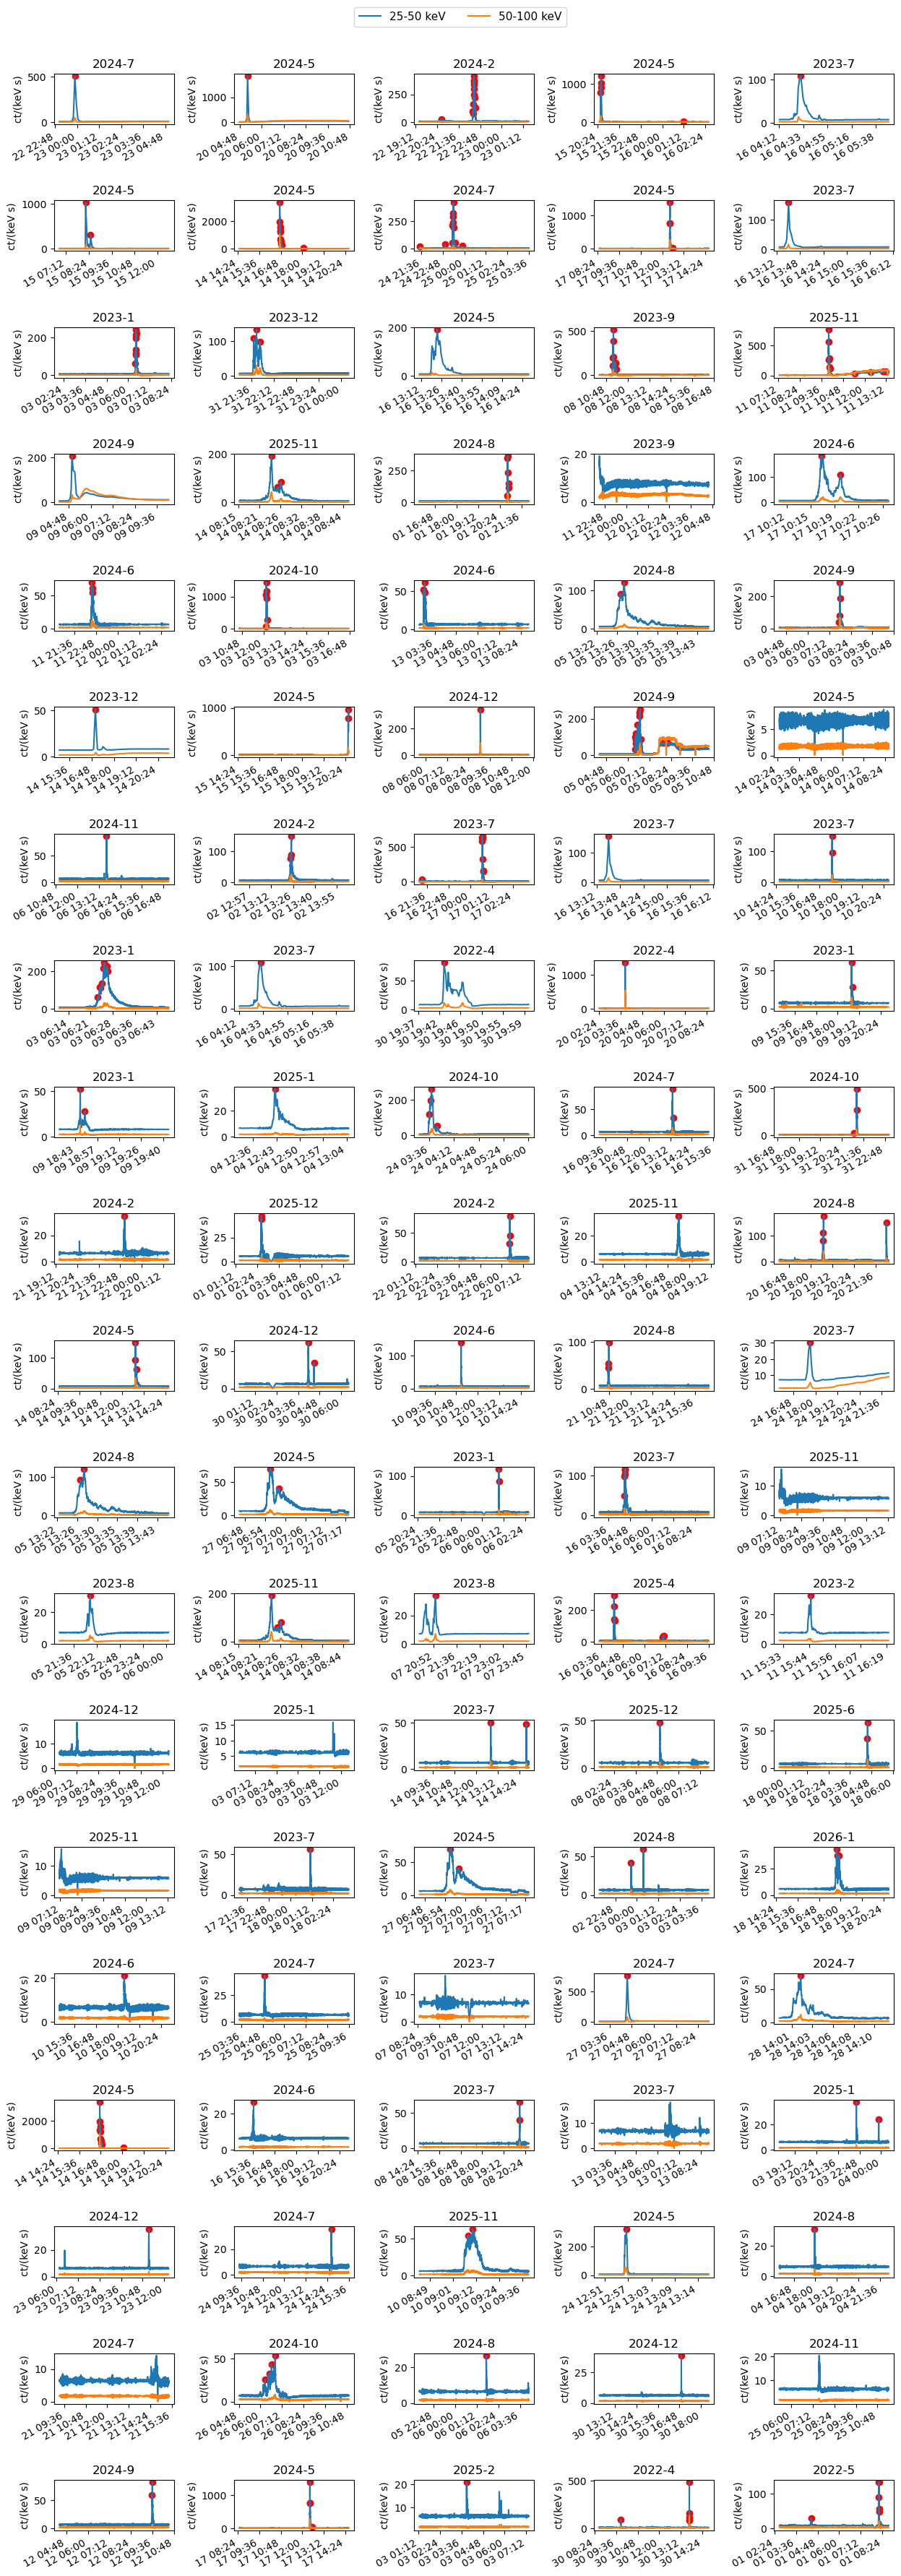

In [90]:
fig, axes = plt.subplots(nrows=20, ncols=5, figsize=(15, 50))
axes = axes.flatten()
i=0
for ind in top100.index:
    ax=axes[i]
    ax.set_ylabel('ct/(keV s)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.set_title(f"{parse_time(top100['start_UTC'].loc[ind]).datetime.year}-{parse_time(top100['start_UTC'].loc[ind]).datetime.month}")
    if ind in indices2:
        sci_df = df_list2[np.where(indices2_array==ind)[1][0]]
        
        start = parse_time(top100['start_UTC'].loc[ind]).datetime
        end = parse_time(top100['end_UTC'].loc[ind]).datetime
        
        #plot_df = sci_df.truncate(start, end)
        plot_df=sci_df.copy()
            
        #plot_df.index = parse_time(plot_df.index).datetime
        
        plot_df.plot(ax=ax, y='25.0 keV-50.0 keV', label='25-50 keV', legend=None)
        plot_df.plot(ax=ax, y='50.0 keV-100.0 keV', label='50-100 keV', legend=None)
        ax.scatter(plot_df.index[peak_locs[i]], plot_df['25.0 keV-50.0 keV'].iloc[peak_locs[i]], color='red')
        
    else:
        ax.plot([0,1],[0,1], color='red')

    date_form = DateFormatter("%d %H:%M")
    ax.xaxis.set_major_formatter(date_form)
    
    i+=1

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=2, fontsize=11)
fig.subplots_adjust(hspace=1.5)
fig.subplots_adjust(wspace=0.5)

plt.show()

In [91]:
data=np.zeros((100, 7))

In [133]:

stats_df = pd.DataFrame(data, columns = ('flare_list_id', 'number_of_peaks', 'rise_time', 'decay_time', 'total_duration', 'strong_hard_x-ray','comments'))


In [134]:
stats_df['flare_list_id']

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
95    0.0
96    0.0
97    0.0
98    0.0
99    0.0
Name: flare_list_id, Length: 100, dtype: float64

In [135]:
stats_df['flare_list_id'] = stats_df['flare_list_id'].astype(int)
i=0
for ind in indices2:
    stats_df.loc[i, 'flare_list_id'] = ind
    i+=1

In [136]:
stats_df['flare_list_id']

0     17678
1     16121
2     12921
3     15873
4      8972
      ...  
95    19855
96    15986
97    24906
98     2083
99     2130
Name: flare_list_id, Length: 100, dtype: int64

In [137]:
stats_df['number_of_peaks'] = stats_df['number_of_peaks'].astype(int)
i=0
for i in range(99):
    stats_df.loc[i, 'number_of_peaks'] = peak_counts[i]

stats_df['number_of_peaks']

0      1
1      1
2     13
3      5
4      1
      ..
95     2
96     4
97     1
98     5
99     0
Name: number_of_peaks, Length: 100, dtype: int64

In [138]:
weak_x = [18, 29, 32, 33, 35, 36, 55, 56, 58, 61, 69, 70, 80, 90, 96]
strong_x = set(np.arange(0, 99, 1).tolist()) - set(weak_x)

In [139]:
stats_df['strong_hard_x-ray'] = stats_df['strong_hard_x-ray'].astype(bool)
for i in range(100):
    if i in weak_x:
        stats_df.loc[i, 'strong_hard_x-ray'] = False
    else:
        stats_df.loc[i, 'strong_hard_x-ray'] = True

In [140]:
stats_df['comments'] = stats_df['comments'].astype(str)

comments = [11, 17, 20, 22, 28, 42, 49, 74, 87, 91]

for i in range(100):
    if i in comments:
        stats_df.loc[i, 'comments'] = 'possible pulses'
    else:
        stats_df.loc[i, 'comments'] = ' '

stats_df.loc[18, 'comments'] = 'wrong time range?'    

In [141]:
stats_df

,flare_list_id,number_of_peaks,rise_time,decay_time,total_duration,strong_hard_x-ray,comments
0,17678,1,0.0,0.0,0.0,True,
1,16121,1,0.0,0.0,0.0,True,
2,12921,13,0.0,0.0,0.0,True,
3,15873,5,0.0,0.0,0.0,True,
4,8972,1,0.0,0.0,0.0,True,
...,...,...,...,...,...,...,...
95,19855,2,0.0,0.0,0.0,True,
96,15986,4,0.0,0.0,0.0,False,
97,24906,1,0.0,0.0,0.0,True,
98,2083,5,0.0,0.0,0.0,True,


In [110]:
list_pulse = stats_df.index[stats_df['comments']=='possible pulses']
stats_df['flare_list_id'].iloc[list_pulse]

11    11949.0
17    18238.0
20    16710.0
22    16752.0
28    19491.0
42    22177.0
49    18944.0
74    31580.0
87    30496.0
91    22261.0
Name: Flare List ID, dtype: float64

In [118]:
pip install tabulate


Note: you may need to restart the kernel to use updated packages.


In [142]:
stats_df.to_markdown()

'|    |   flare_list_id |   number_of_peaks |   rise_time |   decay_time |   total_duration | strong_hard_x-ray   | comments          |\n|---:|----------------:|------------------:|------------:|-------------:|-----------------:|:--------------------|:------------------|\n|  0 |           17678 |                 1 |           0 |            0 |                0 | True                |                   |\n|  1 |           16121 |                 1 |           0 |            0 |                0 | True                |                   |\n|  2 |           12921 |                13 |           0 |            0 |                0 | True                |                   |\n|  3 |           15873 |                 5 |           0 |            0 |                0 | True                |                   |\n|  4 |            8972 |                 1 |           0 |            0 |                0 | True                |                   |\n|  5 |           15844 |                 2 |   

In [143]:
def print_full(x):
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 2000)
    pd.set_option('display.float_format', '{:20,.2f}'.format)
    pd.set_option('display.max_colwidth', None)
    print(x)

In [144]:
print_full(stats_df)

    flare_list_id  number_of_peaks            rise_time           decay_time       total_duration  strong_hard_x-ray           comments
0           17678                1                 0.00                 0.00                 0.00               True                   
1           16121                1                 0.00                 0.00                 0.00               True                   
2           12921               13                 0.00                 0.00                 0.00               True                   
3           15873                5                 0.00                 0.00                 0.00               True                   
4            8972                1                 0.00                 0.00                 0.00               True                   
5           15844                2                 0.00                 0.00                 0.00               True                   
6           15798               10              